## import 

In [3]:
import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import umap.umap_ as umap
from joblib import dump

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(12,7)

c:\Users\smhas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data 

In [31]:
from pathlib import Path
import numpy as np

DATA_DIR = Path("../Data")

X_list = []
y_list = []

for file in sorted(DATA_DIR.rglob("*.npz")):

    print(f"Loading {file.name}")

    data = np.load(file)

    # CSI complex64 -> magnitude float32
    csi = np.abs(data["csi"]).astype(np.float32)

    # metadata
    meta = np.column_stack([
        data["rssi"].astype(np.float32),
        data["channel"].astype(np.float32),
        data["csi_len"].astype(np.float32),
    ])

    # X = [rssi, channel, csi_len, cs0...cs127]
    X_file = np.hstack([
        meta,
        csi
    ])

    label = file.stem.split("_")[0]

    y_file = np.full(
        X_file.shape[0],
        label
    )

    X_list.append(X_file)
    y_list.append(y_file)


# merge all files
X = np.vstack(X_list)
y = np.concatenate(y_list)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Memory:", X.nbytes / 1024**2, "MB")

Loading Empty-Room_0001_000001.npz
Loading Empty-Room_0001_000002.npz
Loading Empty-Room_0001_000003.npz
Loading Empty-Room_0001_000004.npz
Loading Empty-Room_0001_000005.npz
Loading Empty-Room_0001_000006.npz
Loading Empty-Room_0001_000007.npz
Loading Empty-Room_0001_000008.npz
Loading Empty-Room_0001_000009.npz
Loading Empty-Room_0001_000010.npz
Loading Empty-Room_0001_000011.npz


Loading Empty-Room_0001_000012.npz
Loading Empty-Room_0001_000013.npz
Loading Empty-Room_0001_000014.npz
Loading Empty-Room_0001_000015.npz
Loading Empty-Room_0001_000016.npz
Loading Empty-Room_0001_000017.npz
Loading Empty-Room_0001_000018.npz
Loading Empty-Room_0001_000019.npz
Loading Empty-Room_0001_000020.npz
Loading Empty-Room_0001_000021.npz
Loading Empty-Room_0001_000022.npz
Loading Empty-Room_0001_000023.npz
Loading Empty-Room_0001_000024.npz
Loading Empty-Room_0001_000025.npz
Loading Empty-Room_0001_000026.npz
Loading Empty-Room_0001_000027.npz
Loading Empty-Room_0001_000028.npz
Loading Empty-Room_0001_000029.npz
Loading Empty-Room_0001_000030.npz
Loading Empty-Room_0001_000031.npz
Loading Empty-Room_0001_000032.npz
Loading Empty-Room_0001_000033.npz
Loading Empty-Room_0001_000034.npz
Loading Empty-Room_0001_000035.npz
Loading Empty-Room_0001_000036.npz
Loading Empty-Room_0001_000037.npz
Loading Empty-Room_0001_000038.npz
Loading Empty-Room_0001_000039.npz
Loading Empty-Room_0

## data Visualize 

### bar plot count 

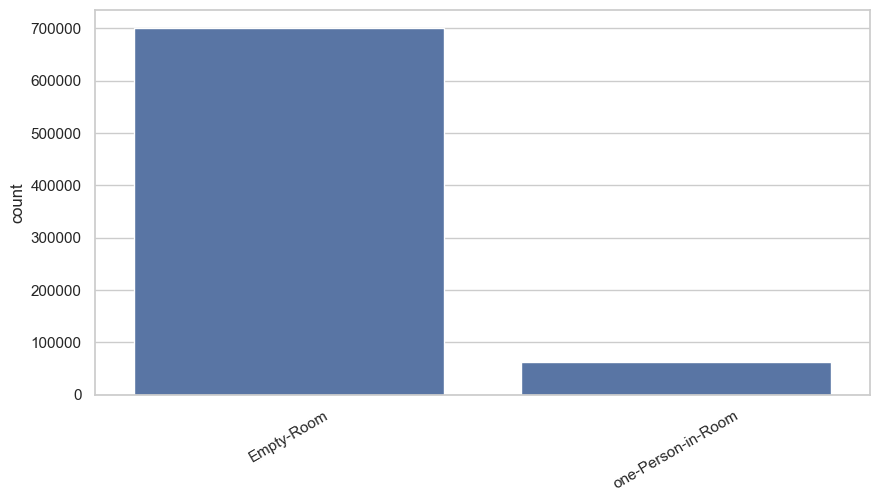

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(x=y)

plt.xticks(rotation=30)

plt.show()

### Mean Heatmap

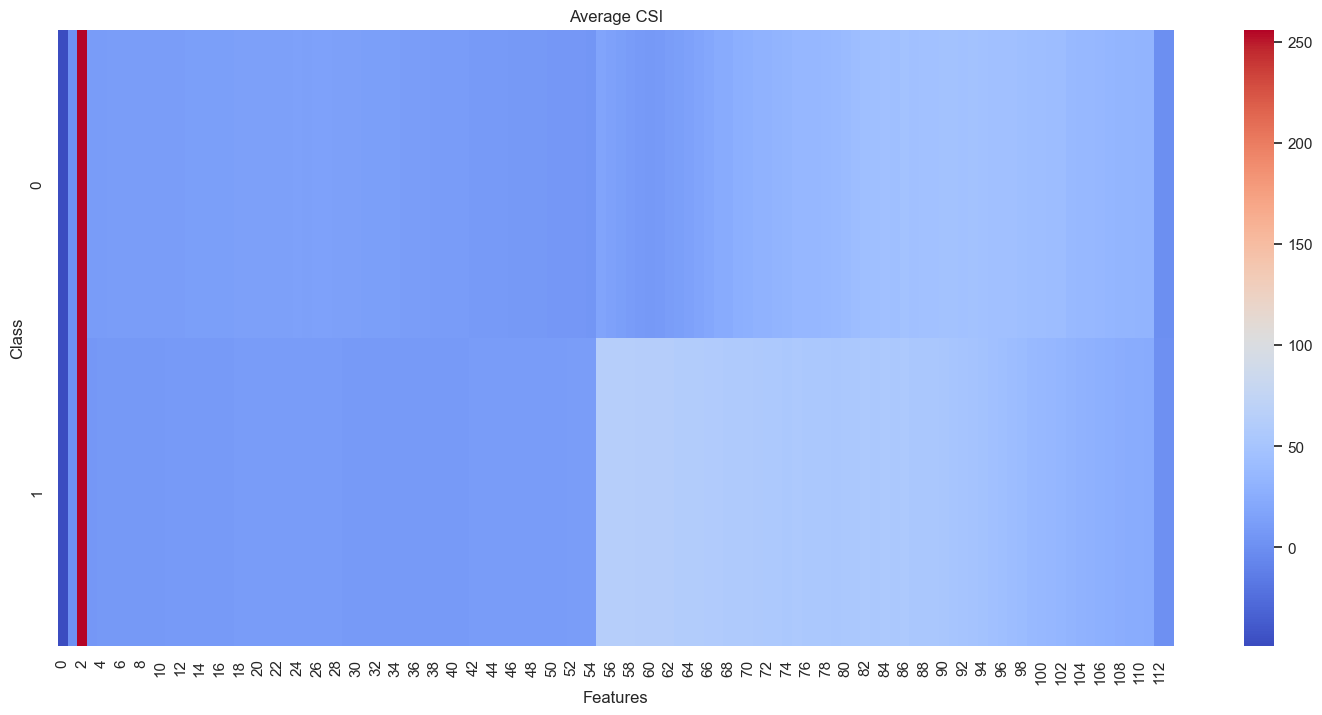

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

classes = np.unique(y)

means = []

for cls in classes:
    means.append(
        X[y == cls].mean(axis=0)
    )

means = np.array(means)


plt.figure(figsize=(18,8))

sns.heatmap(
    means,
    cmap="coolwarm"
)

plt.title("Average CSI")

plt.xlabel("Features")
plt.ylabel("Class")

plt.show()

In [13]:
np.where(np.isnan(X))
np.where(np.isinf(X))


(array([], dtype=int64), array([], dtype=int64))

### PCA 2 dimention 

C:\Users\smhas\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


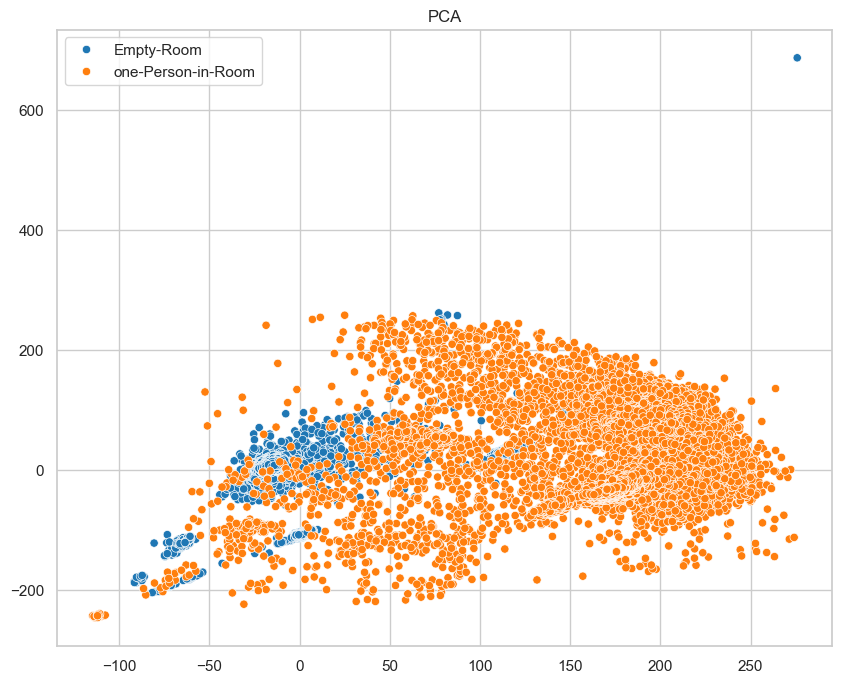

In [15]:
pca=PCA(n_components=2)
# print("Total NaN:", X_scaled.isna().sum().sum())
X_pca=pca.fit_transform(X)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="tab10"
)

plt.title("PCA")

plt.show()

### PCA 3 Dimentional 

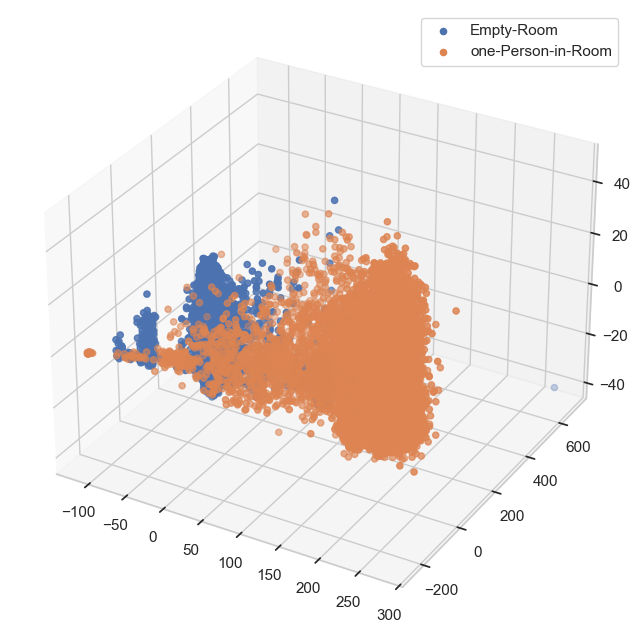

In [21]:
from mpl_toolkits.mplot3d import Axes3D

pca=PCA(n_components=3)

X3=pca.fit_transform(X)

fig=plt.figure(figsize=(10,8))

ax=fig.add_subplot(111,projection='3d')

for l in pd.unique(y):

    idx=y==l

    ax.scatter(
        X3[idx,0],
        X3[idx,1],
        X3[idx,2],
        label=l,
        s=20
    )

plt.legend()

plt.show()

In [ ]:
tsne=TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne=tsne.fit_transform(X)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y
)

plt.title("t-SNE")

plt.show()

c:\Users\smhas\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


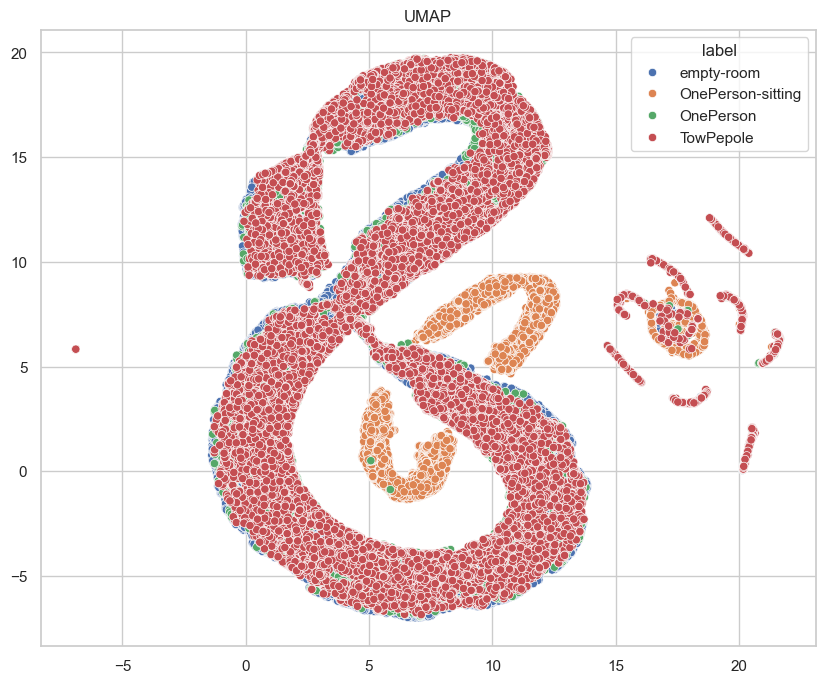

In [ ]:
reducer=umap.UMAP(random_state=42)

embedding=reducer.fit_transform(X)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=embedding[:,0],
    y=embedding[:,1],
    hue=y
)

plt.title("UMAP")

plt.show()

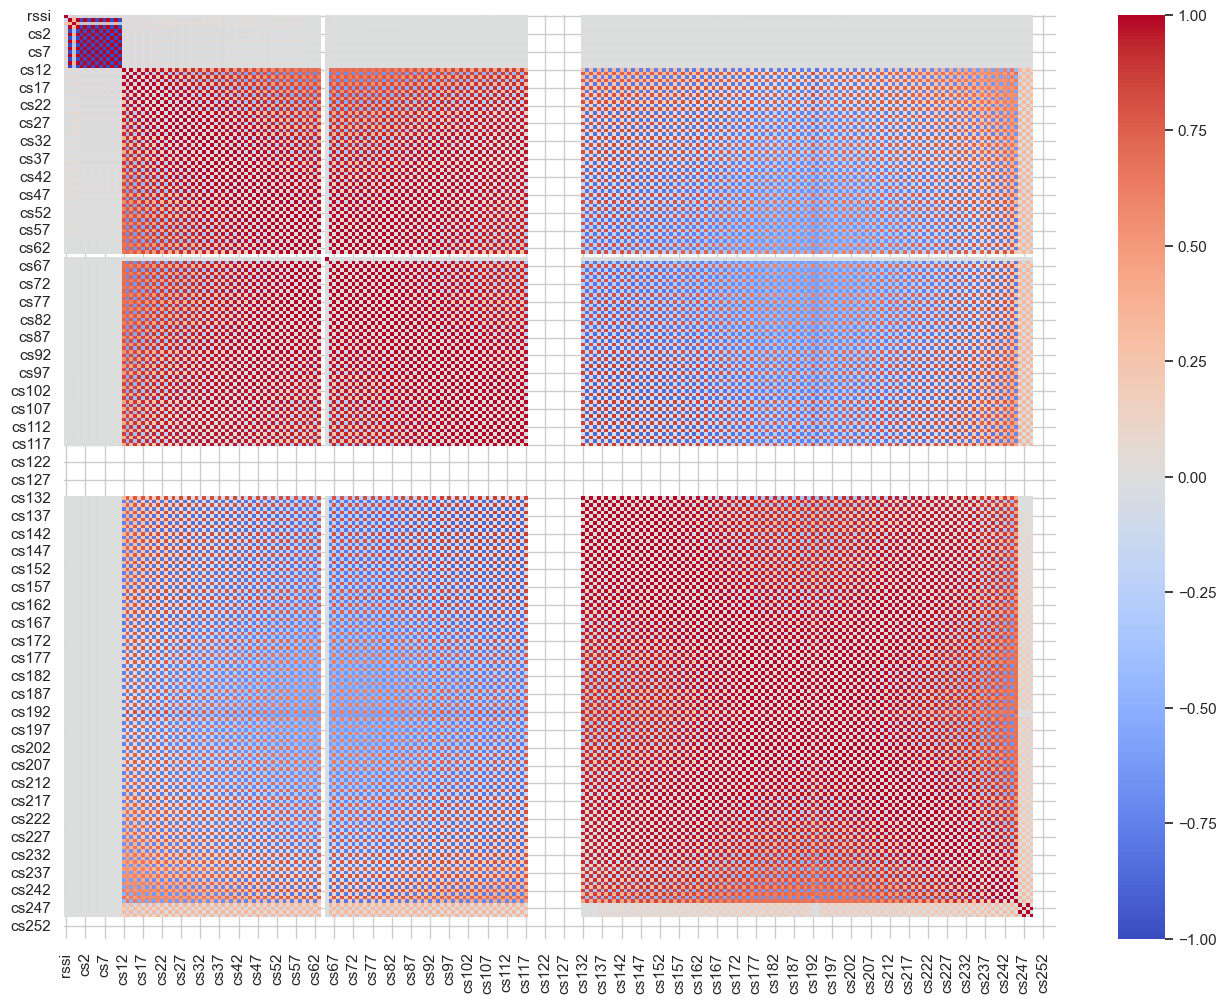

In [ ]:
corr=X.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

## Train Random Forest 

In [32]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()
y=encoder.fit_transform(y)
import numpy as np


print("Original:", X.shape)

zero_cols = np.where(np.all(np.abs(X) == 0, axis=0))[0]
print("Zero columns:", len(zero_cols))
X = np.delete(X, zero_cols, axis=1)

print("After remove:", X.shape)



X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Original: (763625, 131)
Zero columns: 17
After remove: (763625, 114)


In [33]:
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)
pred=rf.predict(X_test)

print(classification_report(y_test,pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00    140125
           1       1.00      1.00      1.00     12600

    accuracy                           1.00    152725
   macro avg       1.00      1.00      1.00    152725
weighted avg       1.00      1.00      1.00    152725



In [36]:

# ذخیره کامل

feature_names = [
    "rssi",
    "channel",
    "csi_len"
]

feature_names += [
    f"cs{i}"
    for i in range(128)
]


feature_names = [
    f for i, f in enumerate(feature_names)
    if i not in zero_cols
]


model_package = {

    "model": model,

    "zero_cols": list(zero_cols),

    "n_features": X_train.shape[1],

    "features": feature_names

}


dump(model_package, "random_forest_model.pkl")



['random_forest_model.pkl']

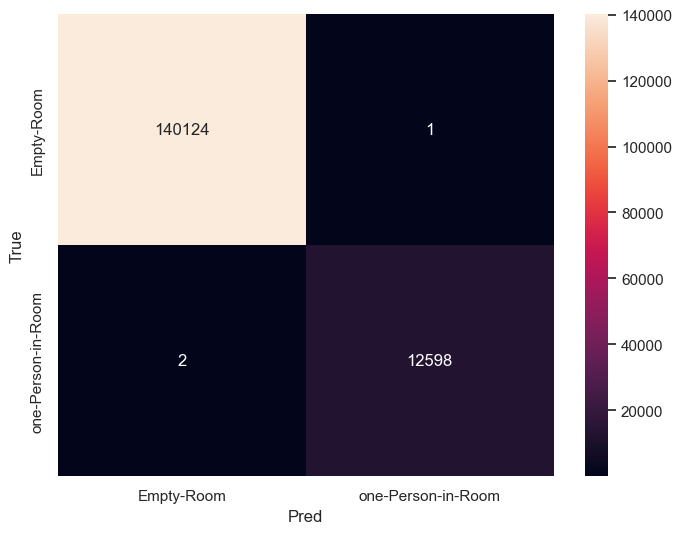

In [37]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Pred")

plt.ylabel("True")

plt.show()

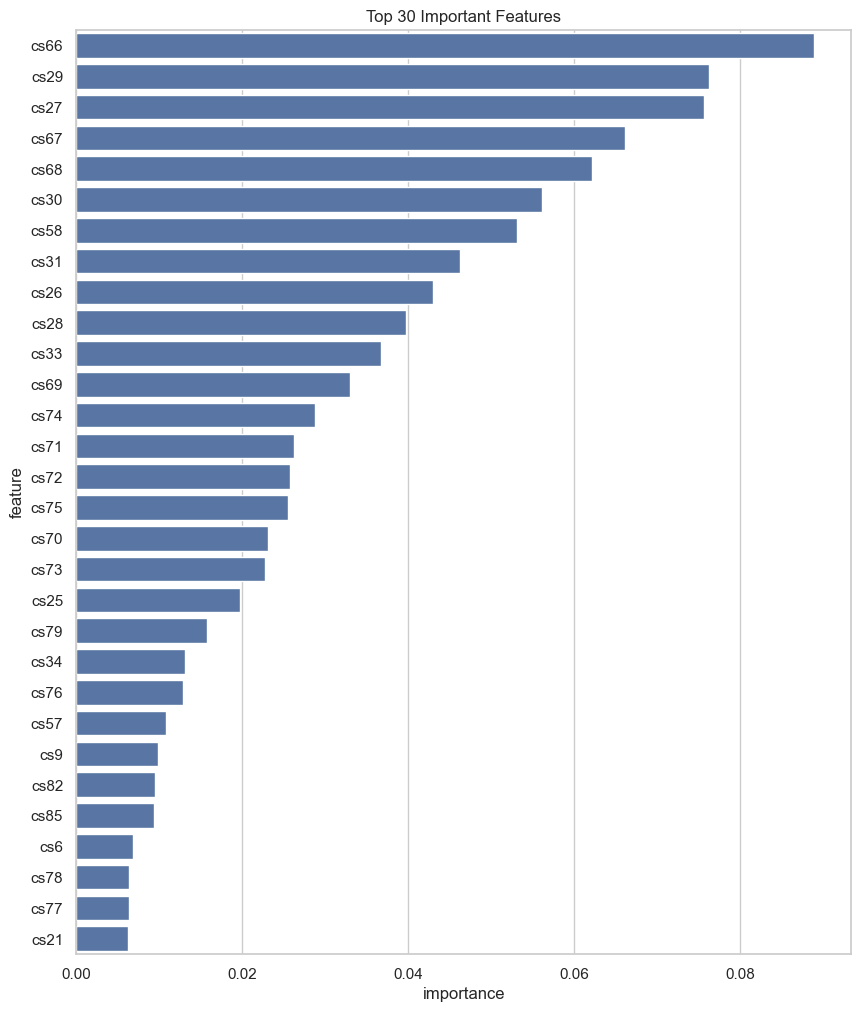

In [42]:
importance = pd.DataFrame({
    "feature":feature_names,
    "importance":rf.feature_importances_
})  

importance=importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(10,12))

sns.barplot(
    data=importance.head(30),
    y="feature",
    x="importance"
)

plt.title("Top 30 Important Features")

plt.show()

## Train Model XGBoost

In [24]:
zero_cols = np.where(
    np.all(
        np.abs(X) == 0,
        axis=0
    )
)[0]

len(zero_cols)

17

In [ ]:
import numpy as np
import joblib


print("Original:", X.shape)

zero_cols = np.where(
    np.all(
        np.abs(X) == 0,
        axis=0
    )
)[0]


print(
    "Zero columns:",
    len(zero_cols)
)

# حذف ستون ها
X = np.delete(
    X,
    zero_cols,
    axis=1
)

print(
    "After remove:",
    X.shape
)

# بعد split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y=encoder.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train

model = XGBClassifier(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.9,

    colsample_bytree=0.9,

    random_state=42

)

model.fit(
    X_train,
    y_train
)



# ذخیره کامل

feature_names = [
    "rssi",
    "channel",
    "csi_len"
]

feature_names += [
    f"cs{i}"
    for i in range(128)
]


feature_names = [
    f for i, f in enumerate(feature_names)
    if i not in zero_cols
]


model_package = {

    "model": model,

    "zero_cols": list(zero_cols),

    "n_features": X_train.shape[1],

    "features": feature_names

}

joblib.dump(
    model_package,
    "xgb_csi_model.pkl"
)

Original: (763625, 131)
Zero columns: 17
After remove: (763625, 114)


['xgb_csi_model.pkl']

In [27]:
model_package
print(model_package.keys())
print(model_package["n_features"])
print(len(model_package["features"]))

dict_keys(['model', 'zero_cols', 'n_features', 'features'])
114
114


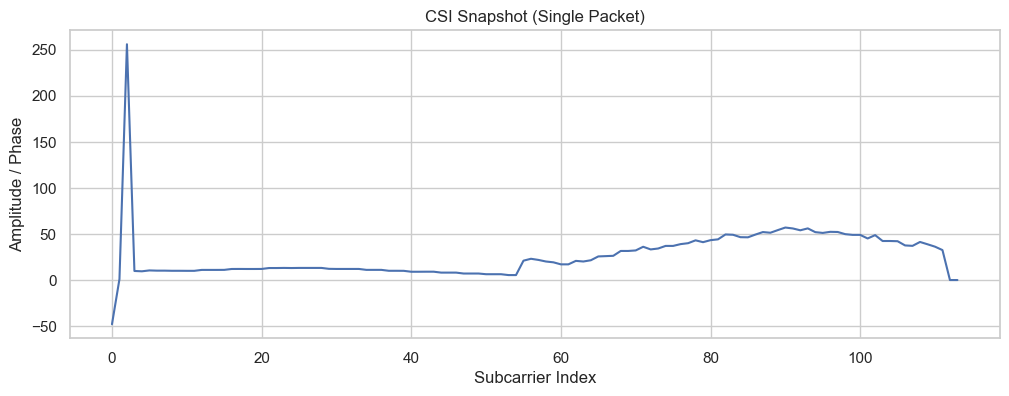

In [ ]:
import matplotlib.pyplot as plt

sample = X[0]

plt.figure(figsize=(12,4))
plt.plot(sample)
plt.title("CSI Snapshot (Single Packet)")
plt.xlabel("Subcarrier Index")
plt.ylabel("Amplitude / Phase")
plt.show()

In [ ]:
import numpy as np
window_size = 50
window = X[:window_size]

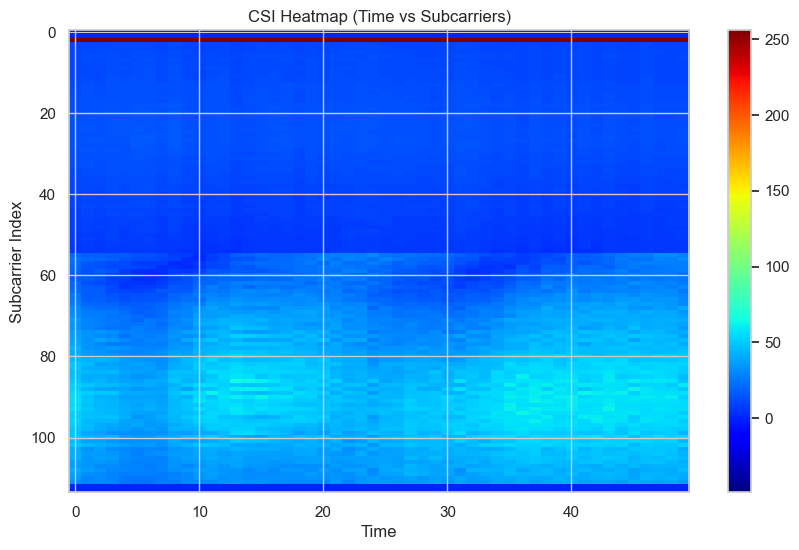

In [35]:
plt.figure(figsize=(10,6))

plt.imshow(window.T, aspect='auto', cmap='jet')

plt.colorbar()
plt.title("CSI Heatmap (Time vs Subcarriers)")
plt.xlabel("Time")
plt.ylabel("Subcarrier Index")

plt.show()